In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("circle.csv")
df.head()

,Unnamed: 0,feature1,feature2,label_y
0,0,8.660254,-5.00000,0
1,1,8.717792,-4.89899,0
2,2,8.773790,-4.79798,0
3,3,8.828277,-4.69697,0
4,4,8.881281,-4.59596,0


In [4]:
df.shape

(400, 4)

In [5]:
df.isna().sum()

Unnamed: 0    0
feature1      0
feature2      0
label_y       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  400 non-null    int64  
 1   feature1    400 non-null    float64
 2   feature2    400 non-null    float64
 3   label_y     400 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 12.6 KB


In [9]:
df = df.drop(['Unnamed: 0'], axis=1)

<Axes: xlabel='feature1', ylabel='feature2'>

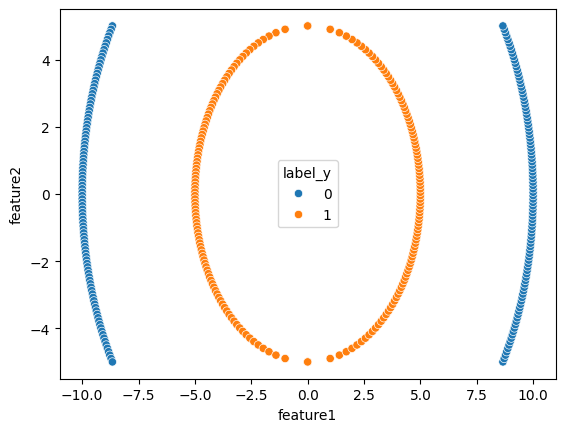

In [17]:
sns.scatterplot(x='feature1', y='feature2',data=df, hue='label_y')

In [18]:
df['label_y'].value_counts()

label_y
0    200
1    200
Name: count, dtype: int64

In [19]:
f1 = df[df['label_y'] == 0]
f2 = df[df['label_y'] == 1]

<Axes: xlabel='feature1', ylabel='feature2'>

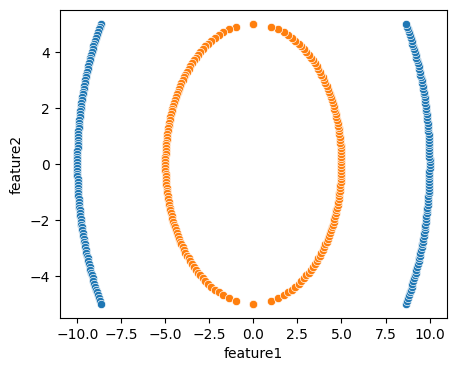

In [28]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=f1, x='feature1', y='feature2')
sns.scatterplot(data=f2, x='feature1', y='feature2')

In [29]:
x = df.drop(['label_y'], axis=1)
y = df[['label_y']]

In [31]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=.15, random_state=42)

In [32]:
dtc = DecisionTreeClassifier()
dtc_model = dtc.fit(xtrain, ytrain)
dtc_model.score(xtrain, ytrain)

1.0

In [33]:
dtc_model.score(xtest, ytest)

1.0

In [34]:
svc = SVC()
svc_model = svc.fit(xtrain, ytrain)
svc_model.score(xtrain, ytrain)

c:\Users\MD Maruf\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


1.0

In [35]:
svc_model.score(xtest, ytest)

1.0

In [38]:
#linear karnel
svm_l = SVC(kernel='linear')
l_model = svm_l.fit(xtrain, ytrain)
l_model.score(xtrain, ytrain)

c:\Users\MD Maruf\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.5823529411764706

In [39]:
l_model.score(xtest, ytest)

0.45

In [52]:
#polynomial kernel
svm_p = SVC(kernel='poly', degree=6)
p_model = svm_p.fit(xtrain, ytrain)
p_model.score(xtrain, ytrain)

c:\Users\MD Maruf\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


1.0

In [53]:
p_model.score(xtest, ytest)

1.0

In [54]:
df.columns

Index(['feature1', 'feature2', 'label_y'], dtype='object')

In [56]:
df['f1_sp'] = df['feature1'] ** 2
df['f2_sp'] = df['feature2'] ** 2
df['f1_f2'] = df['feature1'] * df['feature2']
df.head()

,feature1,feature2,label_y,f1_sp,f2_sp,f1_f2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [57]:
new_x = df.drop(['label_y'], axis=1)
new_y = df[['label_y']]

In [58]:
x_train, x_test, y_train, y_test = train_test_split(new_x, new_y, test_size=0.1, random_state=42)

In [59]:
new_svm_model = svm_p.fit(x_train, y_train)
new_svm_model.score(x_train, y_train)

c:\Users\MD Maruf\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


1.0

In [60]:
new_svm_model.score(x_test, y_test)

1.0